In [21]:
import argparse
import csv
import os
from pathlib import Path
from typing import Dict, List, Sequence
import numpy as np
import yaml
import andes

import sys as _sys

NOTEBOOK_DIR = Path("..").resolve()
TO_EXPORT = NOTEBOOK_DIR
_sys.path.insert(0, str(TO_EXPORT))
from data_generation.extract_metrics import export_plotter_all, extract_simulation_row

In [22]:
def _resolve_case_path(case: str) -> str:
    case_path = andes.get_case(case)
    if os.path.exists(case_path):
        return case_path
    if os.path.exists(case):
        return case
    raise FileNotFoundError(f"Case not found: {case}")


def _as_list(value) -> List:
    if value is None:
        return []
    if isinstance(value, list):
        return value
    return [value]


def _build_fieldnames(pq_names: Sequence[str], n_ibr: int, include_plotter: bool) -> List[str]:
    fieldnames = [
        "sim_id",
        "seed",
        "success",
        "base_load_scale",
        "load_step_scale",
        "load_step_time",
        "base_load_p_total",
        "base_load_q_total",
        "DELTA_PQ_tot",
        "M_agg",
        "D_agg",
        "time_max_dev",
        "rocof_max_COI",
        "rocof_min_COI",
        "devdown_COI",
        "devup_COI",
    ]
    for i in range(1, n_ibr + 1):
        fieldnames.append(f"M_{i}")
        fieldnames.append(f"D_{i}")
    for name in pq_names:
        fieldnames.append(f"DELTA_P_{name}")
        fieldnames.append(f"DELTA_Q_{name}")
    for i in range(1, n_ibr + 1):
        fieldnames.append(f"Delta_P_IBR_{i}")
    if include_plotter:
        fieldnames.append("plotter_csv")
    return fieldnames


def load_config(path: str) -> Dict:
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

In [23]:
def add_measurement_devices(ss):
    """Add BusROCOF at every bus."""
    for bus in ss.Bus.as_df().idx.values:
        ss.add(
            model="BusROCOF",
            idx=f"BusROCOF_{bus}",
            name=f"BusROCOF {bus}",
            param_dict=dict(bus=bus, Tr=0.02, Tw=0.1, Tf=0.02),
        )

     # Add PMU only if missing
    existing = list(ss.PMU.as_df().bus.values) if ss.PMU.n > 0 else []
    for bus in ss.Bus.as_df().idx.values:
        if bus not in existing:
            ss.add(model="PMU", param_dict=dict(bus=bus))

In [132]:
def run_single_sim(cfg: Dict, rng: np.random.Generator, case_path: str, base_scale: float, step_scale: float):
    ss = andes.load(case_path, setup=False)
    ss.config.freq = float(50)
    
    add_measurement_devices(ss)
    regcv1_ids = ss.REGCV1.name.v
    M_vec = rng.uniform(cfg["ibr"]["M_range"][0], cfg["ibr"]["M_range"][1], size=len(regcv1_ids))
    D_vec = rng.uniform(cfg["ibr"]["D_range"][0], cfg["ibr"]["D_range"][1], size=len(regcv1_ids))

    # Apply base load scale
    for uid in range(ss.PQ.n):
        ss.PQ.p0.v[uid] = ss.PQ.p0.v[uid] * base_scale
        ss.PQ.q0.v[uid] = ss.PQ.q0.v[uid] * base_scale
    for uid in range(ss.PV.n):
        ss.PV.p0.v[uid] = ss.PV.p0.v[uid] * base_scale
        ss.PV.q0.v[uid] = ss.PV.q0.v[uid] * base_scale
    
    ss.REGCV1.M.v, ss.REGCV1.D.v = M_vec, D_vec

    ss.PQ.config.p2p = 1
    ss.PQ.config.q2q = 1
    ss.PQ.config.p2z = 0
    ss.PQ.config.q2z = 0
    ss.PQ.config.p2i = 0
    ss.PQ.config.q2i = 0
    ss.PQ.config.pq2z = 0

    pq_p_before, pq_q_before = ss.PQ.p0.v, ss.PQ.q0.v  
    
    # for dev in _as_list(cfg["load"].get("pq_names")):
    #     ss.add(model='Alter', param_dict=dict(t=cfg["tds"]["load_step_time"], model='PQ', dev=dev, src='Ppf', attr='v', method='*', amount=step_scale))
    #     ss.add(model='Alter', param_dict=dict(t=cfg["tds"]["load_step_time"], model='PQ', dev=dev, src='Qpf', attr='v', method='*', amount=step_scale))
    # ss.add(model='Alter', param_dict=dict(t=1, model='REGCV1', dev="REGCV1_2", src='Pref', attr='v', method='+', amount=4.3))
    # ss.add(model='Alter', param_dict=dict(t=1, model='TGOV1N', dev="TGOV1_2", src='pout', attr='v', method='=', amount=6.3))
    # ss.add(model='Alter', param_dict=dict(t=1, model='TGOV1N', dev="TGOV1_2", src='paux', attr='v', method='=', amount=6.3))
    # ss.add(model='Alter', param_dict=dict(t=10, model='PV', dev=5, src='p0', attr='v', method='=', amount=6.3))
    # ss.add(model='Alter', param_dict=dict(t=10, model='TGOV1N', dev="TGOV1_2", src='pref', attr='v', method='+', amount=2))
    # ss.add(model='Alter', param_dict=dict(t=10, model='TGOV1N', dev="TGOV1_2", src='pout', attr='v', method='+', amount=2))
    # ss.add(model='Alter', param_dict=dict(t=10, model='TGOV1N', dev="TGOV1_2", src='tm0', attr='v', method='-', amount=0.5))
    # ss.add(model='Alter', param_dict=dict(t=1, model='GENROU', dev="GENROU_2", src='Pe', attr='v', method='=', amount=6.3))
    ss.setup()
    ss.PFlow.run()

    ss.TDS.config.no_tqdm = bool(cfg["tds"].get("no_tqdm", True))
    ss.TDS.config.criteria = int(cfg["tds"].get("criteria", 0))
    ss.TDS.config.tol = float(cfg["tds"].get("tol", 1e-6))
    ss.TDS.config.tf = float(cfg["tds"]["t_end"])
    ss.TDS.config.tstep = float(cfg["tds"]["t_step"])
    ss.TDS.config.fixt = int(cfg["tds"].get("fixt", 0))
    ss.TDS.config.method = str(cfg["tds"].get("method", "backeuler"))
    ss.TDS.config.honest = int(cfg["tds"].get("honest", 0))
    ss.TDS.config.max_iter = int(cfg["tds"].get("max_iter", 35))
    ss.TDS.config.shrinkt = int(cfg["tds"].get("shrinkt", 1))

    ss.TDS.init()

    # for uid in range(ss.PQ.n):
    # # # for dev in _as_list(cfg["load"].get("pq_names")):
    #     p = ss.PQ.p0.v[uid] * step_scale
    #     q = ss.PQ.q0.v[uid] * step_scale
    #     ss.PQ.p0.v[uid], ss.PQ.Ppf.v[uid] = p, p
    #     ss.PQ.q0.v[uid], ss.PQ.Qpf.v[uid] = q, q
    #     # ss.add(model='Alter', param_dict=dict(t=cfg["tds"]["load_step_time"], model='PQ', dev=dev, src='Ppf', attr='v', method='*', amount=step_scale))
    #     # ss.add(model='Alter', param_dict=dict(t=cfg["tds"]["load_step_time"], model='PQ', dev=dev, src='Qpf', attr='v', method='*', amount=step_scale))
    
    success = bool(ss.TDS.run())
    ss.TDS.load_plotter()

    pq_p_after, pq_q_after = ss.PQ.Ppf.v, ss.PQ.Qpf.v  

    return ss

In [133]:
ss = run_single_sim(load_config("experiments/generation.yaml"), np.random.default_rng(int(42)), "data_generation/andes_cases/ieee39_full_ibrs.xlsx", base_scale=1, step_scale=.8)

GENROU (xl <= xd2) out of typical upper limit.

   idx     | values | limit
-----------+--------+------
 GENROU_2  | 0.005  | 0.004
 GENROU_3  | 0.004  | 0.000
 GENROU_4  | 0.002  | 0.000
 GENROU_5  | 0.005  | 0.000
 GENROU_7  | 0.003  | 0.000
 GENROU_10 | 0.000  | 0.000




In [122]:
ss.TGOV1N.params.keys()

odict_keys(['idx', 'u', 'name', 'syn', 'Tn', 'wref0', 'R', 'VMAX', 'VMIN', 'T1', 'T2', 'T3', 'Dt', 'Sg', 'ug', 'Vn'])

In [134]:
help(ss.GENROU.doc)

Help on method doc in module andes.core.model.model:

doc(max_width=78, export='plain') method of andes.models.synchronous.genrou.GENROU instance
    Retrieve model documentation as a string.



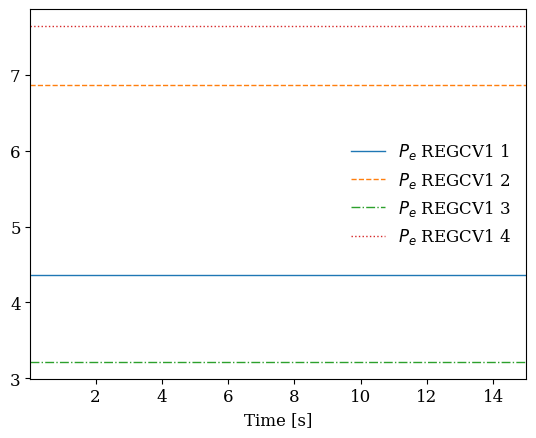

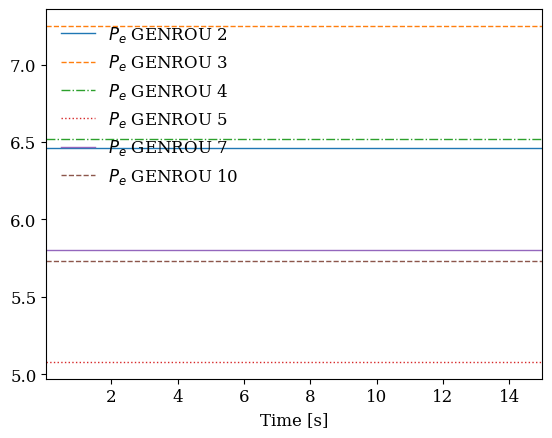

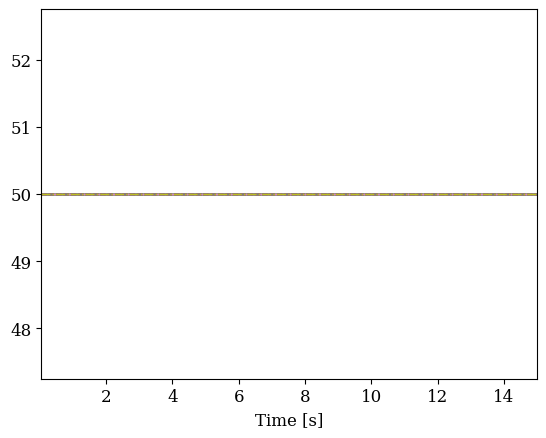

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [135]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

plotter = ss.TDS.plotter
plotter.plot(plotter.find("Pe REGCV1", idx_only=True))
plotter.plot(plotter.find("Pe GENROU", idx_only=True))
plotter.plot(plotter.find("f BusROCOF", idx_only=True), ycalc=lambda x: x * 50)
# time = np.asarray(plotter.get_values(0), dtype=float).reshape(-1)
# f_coi = np.asarray(plotter.get_values(plotter.find("Pe REGCV1", idx_only=True)), dtype=float).reshape(-1) * 50
# r_coi = np.gradient(f_coi, float(ss.TDS.config.tstep), axis=0)
# # f_coi.shape
# plt.plot(f_coi)
# plt.show()